# Explore here

In [64]:
# Librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# Data 

df = pd.read_csv('../data/raw/Lake_Bilancino.csv')
df

,Date,Rainfall_S_Piero,Rainfall_Mangona,Rainfall_S_Agata,Rainfall_Cavallina,Rainfall_Le_Croci,Temperature_Le_Croci,Lake_Level,Flow_Rate
0,03/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
1,04/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
2,05/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
3,06/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
4,07/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.44,0.31
...,...,...,...,...,...,...,...,...,...
6598,26/06/2020,0.0,0.0,0.0,0.0,0.0,22.50,250.85,0.60
6599,27/06/2020,0.0,0.0,0.0,0.0,0.0,23.40,250.84,0.60
6600,28/06/2020,0.0,0.0,0.0,0.0,0.0,21.50,250.83,0.60
6601,29/06/2020,0.0,0.0,0.0,0.0,0.0,23.20,250.82,0.60


In [66]:
# Aislamos los datos pertinentes al problema

df2 =df[['Date','Lake_Level']]
df2

,Date,Lake_Level
0,03/06/2002,249.43
1,04/06/2002,249.43
2,05/06/2002,249.43
3,06/06/2002,249.43
4,07/06/2002,249.44
...,...,...
6598,26/06/2020,250.85
6599,27/06/2020,250.84
6600,28/06/2020,250.83
6601,29/06/2020,250.82


In [69]:
df2.loc[:,'Date'] = pd.to_datetime(df2['Date'], errors='coerce', dayfirst=True)
df2

,Date,Lake_Level
0,2002-06-03,249.43
1,2002-06-04,249.43
2,2002-06-05,249.43
3,2002-06-06,249.43
4,2002-06-07,249.44
...,...,...
6598,2020-06-26,250.85
6599,2020-06-27,250.84
6600,2020-06-28,250.83
6601,2020-06-29,250.82


In [70]:
# Transformamos la columana de fecha en el index

df2.index = df2['Date']
df2.drop('Date',axis=1,inplace=True)
df2

/var/folders/3p/lzyp6b9542b_8mk_q04l5p100000gn/T/ipykernel_11081/4098007734.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop('Date',axis=1,inplace=True)


,Lake_Level
Date,
2002-06-03,249.43
2002-06-04,249.43
2002-06-05,249.43
2002-06-06,249.43
2002-06-07,249.44
...,...
2020-06-26,250.85
2020-06-27,250.84
2020-06-28,250.83


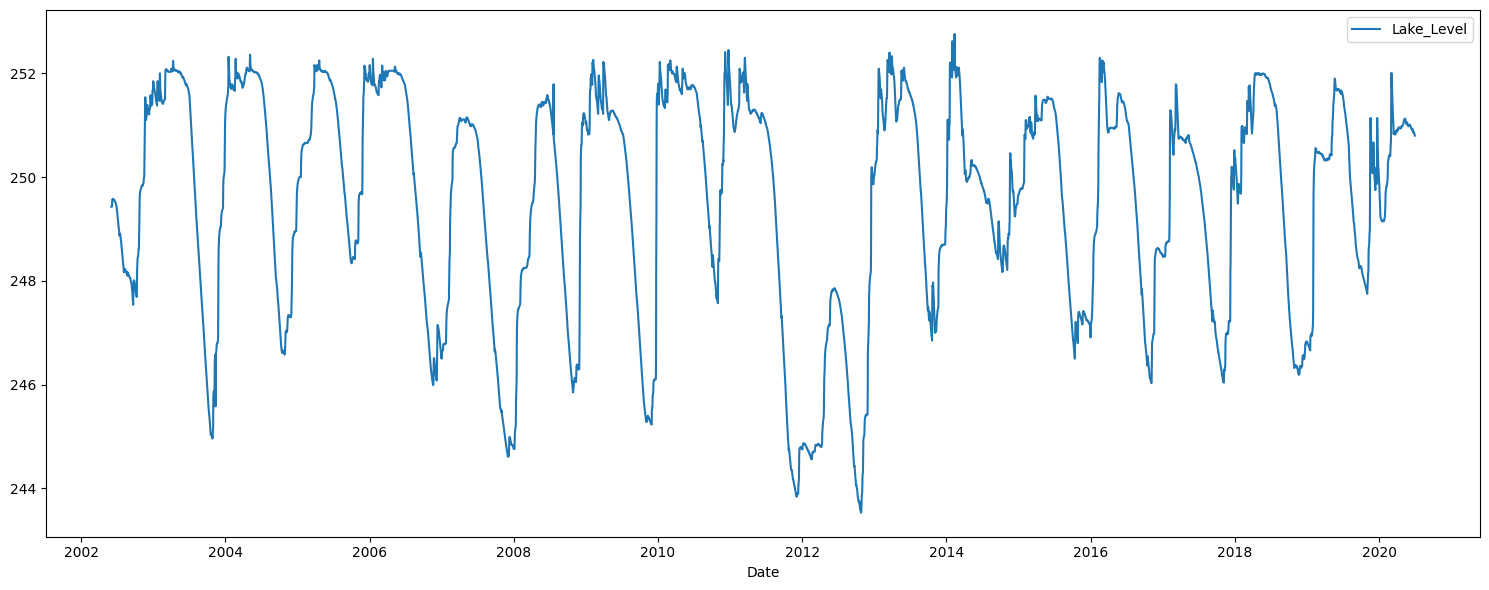

In [71]:
# Visualización Serie Temporal

fig, axis = plt.subplots(figsize = (15, 6))

sns.lineplot(data = df2)

plt.tight_layout()

plt.show()


In [72]:
# Descomposición de la serie

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df2, period = 365)
decomposition

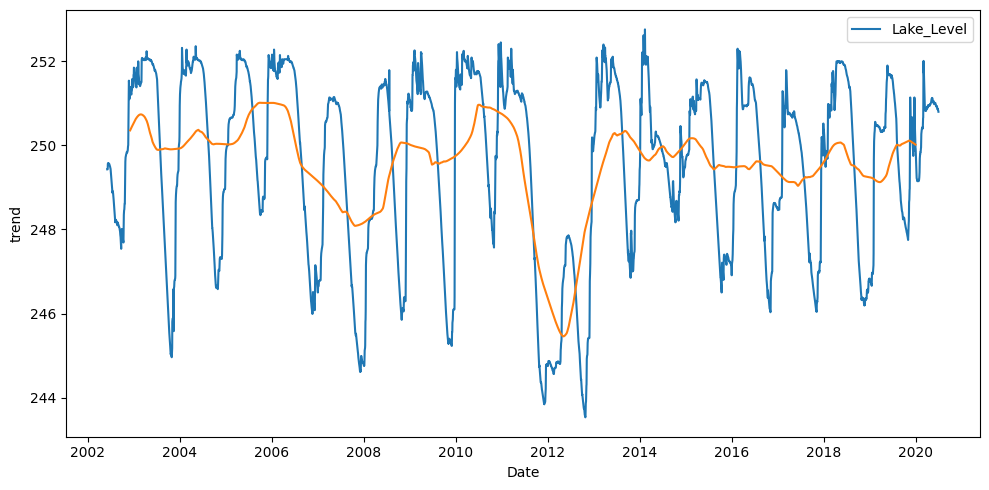

In [73]:
# Análisis de tendencia

tendencia = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df2)
sns.lineplot(data = tendencia)

plt.tight_layout()

plt.show()

Se observa estabilidad en el nivel del lago, con su períodos comunes de sequía más o menos graves.

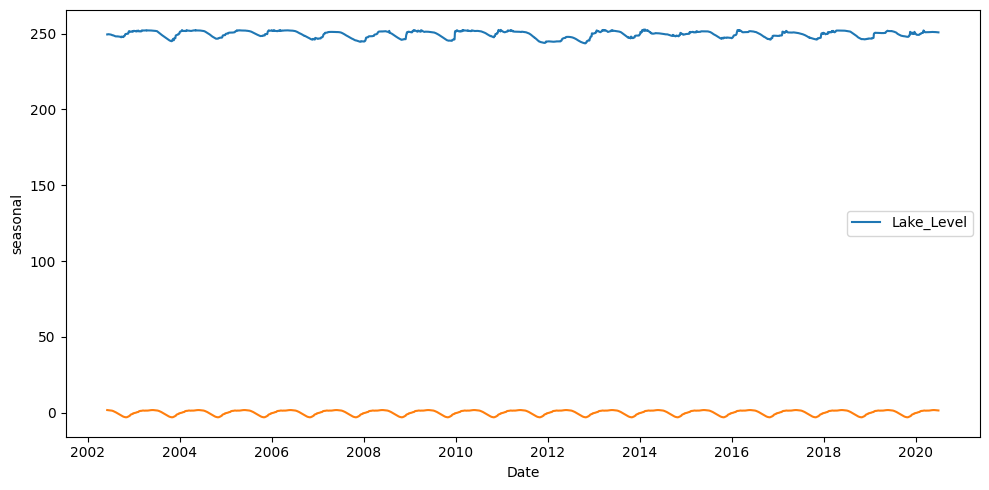

In [74]:
# Análisis de estacionalidad

seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df2)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

Se observa una alta estacionalidad en el nivel del lago, correlacionado a las estaciones del año.

In [75]:
# Evaluación de estacionalidad (Dickey-Fuller Test)

from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(df2)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -6.880991e+00
p-value                        1.433634e-09
#Lags Used                     3.500000e+01
Number of Observations Used    6.567000e+03
Critical Value (1%)           -3.431346e+00
Critical Value (5%)           -2.861980e+00
Critical Value (10%)          -2.567004e+00
dtype: float64

p-values es muy bajo, por lo que la serie es estacionaria

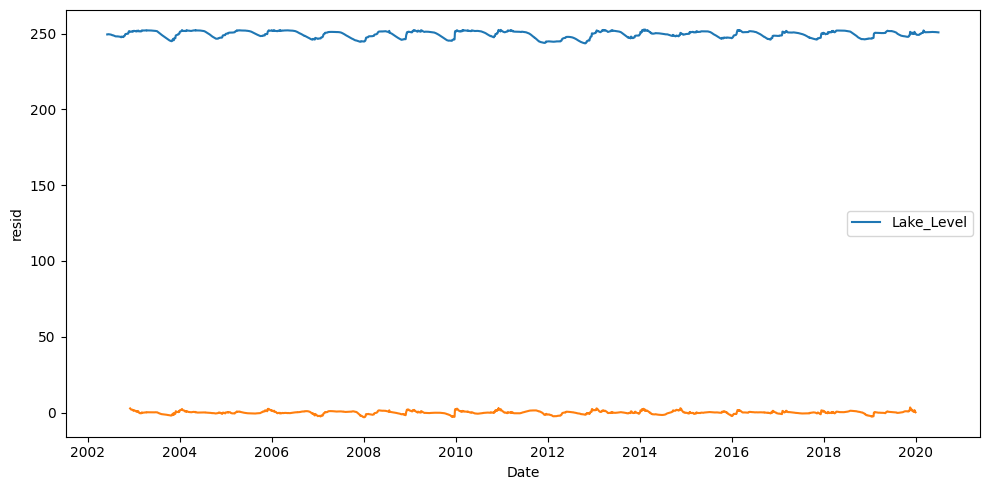

In [76]:
# Análisis de variabilidad (Residuos)

residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df2)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

Residuos muy pequeños, no son relevantes para la predicción

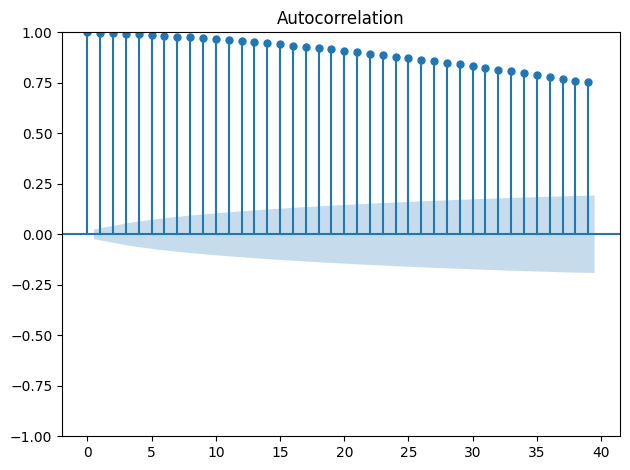

In [77]:
# Análisis de autocorrelación

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df2)

plt.tight_layout()

plt.show()

Los componenetes de la serie son autorregresivos (altamente correlacionados), lo que sigue la lógica de las conclusiones anteriores.

In [78]:
# Definimos el modelo Auto_arima

from pmdarima import auto_arima

modelo = auto_arima(df2,
                    seasonal=True,                     
                    trace=True)    
print(modelo.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-12552.739, Time=1.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-11118.435, Time=0.22 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-12469.605, Time=0.43 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-12130.639, Time=0.45 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-11120.409, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-12561.114, Time=0.93 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-12395.703, Time=0.56 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-12554.341, Time=0.88 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-12598.110, Time=2.01 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-12479.939, Time=0.81 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-12601.955, Time=2.45 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=3.42 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=-12604.452, Time=2.65 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=-12616.475, Time=2.66 sec
 ARIMA(0,1,4

In [79]:
# Predicciones del modelo

predicciones = modelo.predict(n_periods=30)
predicciones

2020-07-01    250.789929
2020-07-02    250.783076
2020-07-03    250.777528
2020-07-04    250.773203
2020-07-05    250.768863
2020-07-06    250.765152
2020-07-07    250.761209
2020-07-08    250.757766
2020-07-09    250.754067
2020-07-10    250.750821
2020-07-11    250.747330
2020-07-12    250.744262
2020-07-13    250.740963
2020-07-14    250.738062
2020-07-15    250.734943
2020-07-16    250.732199
2020-07-17    250.729250
2020-07-18    250.726655
2020-07-19    250.723868
2020-07-20    250.721413
2020-07-21    250.718779
2020-07-22    250.716457
2020-07-23    250.713967
2020-07-24    250.711770
2020-07-25    250.709416
2020-07-26    250.707339
2020-07-27    250.705114
2020-07-28    250.703149
2020-07-29    250.701045
2020-07-30    250.699187
Freq: D, dtype: float64

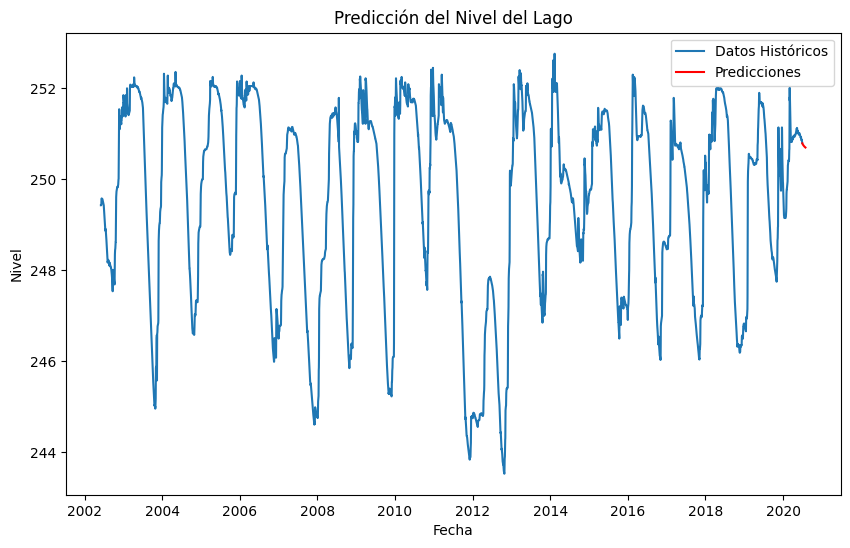

In [86]:
# Graficar las predicciones

plt.figure(figsize=(10,6))
plt.plot(df2, label='Datos Históricos')
plt.plot(predicciones, label='Predicciones', color='red')
plt.title("Predicción del Nivel del Lago")
plt.xlabel("Fecha")
plt.ylabel("Nivel")
plt.legend()
plt.show()

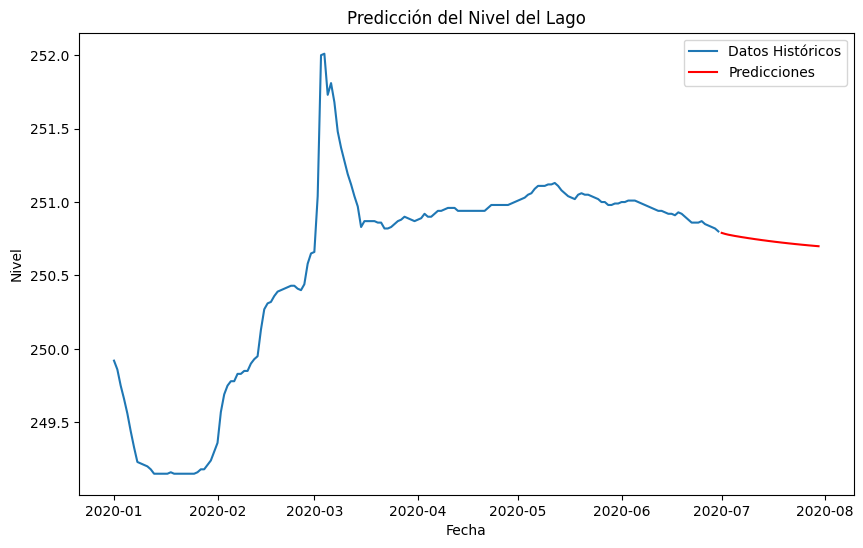

In [89]:
# Grafico aumentado

df2_filtrado = df2[df2.index >= '2020-01-01']

plt.figure(figsize=(10,6))
plt.plot(df2_filtrado, label='Datos Históricos')
plt.plot(predicciones, label='Predicciones', color='red')
plt.title("Predicción del Nivel del Lago")
plt.xlabel("Fecha")
plt.ylabel("Nivel")
plt.legend()
plt.show()

In [90]:
import pickle

with open('arima_3-1-4.pkl', 'wb') as archivo:
    pickle.dump(modelo, archivo)